# 🏠 Dubai & UAE Real Estate Market Analysis
## Exploratory Data Analysis (EDA)

**Author:** Rohini Padamata  
**Date:** April 2026  
**Tools Used:** Python, Pandas, Matplotlib, Seaborn  
**Dataset:** Dubai/UAE Rental Properties Dataset (73,742 records)

---

## 📌 Project Overview
This project explores the UAE real estate rental market using a dataset of over 73,000 property listings. The goal is to uncover key trends in rental prices, property types, and city-wise distribution to support data-driven decision making in the real estate sector.

## 🎯 Key Questions Explored
- What types of properties are most common in UAE?
- Which city has the highest average rent?
- How does rent vary by property type?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('dubai_properties.csv')

# Show first 5 rows
df.head()

,Address,Rent,Beds,Baths,Type,Area_in_sqft,Rent_per_sqft,Rent_category,Frequency,Furnishing,Purpose,Posted_date,Age_of_listing_in_days,Location,City,Latitude,Longitude
0,"The Gate Tower 2, The Gate Tower, Shams Gate D...",124000,3,4,Apartment,1785,69.467787,Medium,Yearly,Unfurnished,For Rent,2024-03-07,45,Al Reem Island,Abu Dhabi,24.493598,54.407841
1,"Water's Edge, Yas Island, Abu Dhabi",140000,3,4,Apartment,1422,98.452883,Medium,Yearly,Unfurnished,For Rent,2024-03-08,44,Yas Island,Abu Dhabi,24.494022,54.607372
2,"Al Raha Lofts, Al Raha Beach, Abu Dhabi",99000,2,3,Apartment,1314,75.342466,Medium,Yearly,Furnished,For Rent,2024-03-21,31,Al Raha Beach,Abu Dhabi,24.485931,54.600939
3,"Marina Heights, Marina Square, Al Reem Island,...",220000,3,4,Penthouse,3843,57.246942,High,Yearly,Unfurnished,For Rent,2024-02-24,57,Al Reem Island,Abu Dhabi,24.493598,54.407841
4,"West Yas, Yas Island, Abu Dhabi",350000,5,7,Villa,6860,51.020408,High,Yearly,Unfurnished,For Rent,2024-02-16,65,Yas Island,Abu Dhabi,24.494022,54.607372


In [2]:
# How many rows and columns?
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:", df.columns.tolist())

# Basic info
df.info()

Shape of dataset: (73742, 17)

Columns: ['Address', 'Rent', 'Beds', 'Baths', 'Type', 'Area_in_sqft', 'Rent_per_sqft', 'Rent_category', 'Frequency', 'Furnishing', 'Purpose', 'Posted_date', 'Age_of_listing_in_days', 'Location', 'City', 'Latitude', 'Longitude']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73742 entries, 0 to 73741
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Address                 73742 non-null  object 
 1   Rent                    73742 non-null  int64  
 2   Beds                    73742 non-null  int64  
 3   Baths                   73742 non-null  int64  
 4   Type                    73742 non-null  object 
 5   Area_in_sqft            73742 non-null  int64  
 6   Rent_per_sqft           73742 non-null  float64
 7   Rent_category           73742 non-null  object 
 8   Frequency               73742 non-null  object 
 9   Furnishing              73742 non-null  obje

In [3]:
# Basic statistics
df.describe()

,Rent,Beds,Baths,Area_in_sqft,Rent_per_sqft,Age_of_listing_in_days,Latitude,Longitude
count,7.374200e+04,73742.000000,73742.000000,73742.000000,73742.000000,73742.000000,73023.000000,73023.000000
mean,1.479250e+05,2.162811,2.650213,2054.053552,88.057754,74.261547,24.918929,55.053133
std,3.069658e+05,1.578155,1.632997,3003.919252,66.534400,72.346767,0.569356,0.653722
min,0.000000e+00,0.000000,1.000000,74.000000,0.000000,11.000000,15.175847,43.351928
25%,5.499900e+04,1.000000,2.000000,850.000000,39.977778,30.000000,24.493598,54.607372
50%,9.800000e+04,2.000000,2.000000,1334.000000,71.428571,52.000000,25.078641,55.238209
75%,1.700000e+05,3.000000,3.000000,2130.000000,118.483412,95.000000,25.197978,55.367138
max,5.500000e+07,12.000000,11.000000,210254.000000,2182.044888,2276.000000,25.920310,56.361294


In [4]:
# What types of properties are there?
print(df['Type'].value_counts())

print("\n")

# Which cities are in the dataset?
print(df['City'].value_counts())

Apartment               56534
Villa                   12883
Townhouse                3421
Hotel Apartment           465
Penthouse                 270
Villa Compound            107
Residential Building       44
Residential Floor          12
Residential Plot            6
Name: Type, dtype: int64


Dubai             34250
Abu Dhabi         23324
Sharjah            9516
Ajman              4704
Al Ain             1040
Ras Al Khaimah      816
Umm Al Quwain        65
Fujairah             27
Name: City, dtype: int64


## 📊 Analysis 1: Property Types in UAE

Here we explore the distribution of property types across the UAE rental market. 
This helps us understand what kind of properties dominate the market.

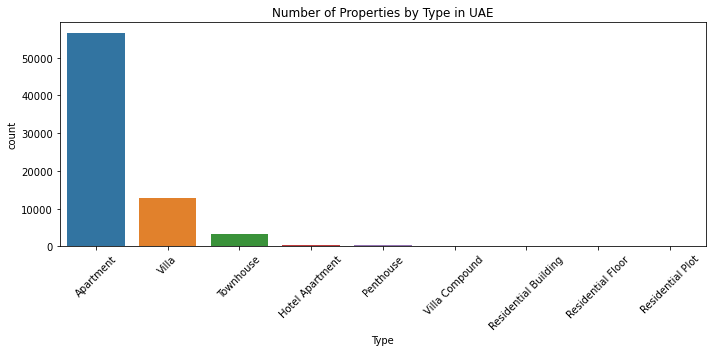

In [5]:
# Bar chart - Property types
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Type', order=df['Type'].value_counts().index)
plt.title('Number of Properties by Type in UAE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 🏙️ Analysis 2: Average Rent by City

Here we compare average rental prices across all UAE emirates. 
This reveals which cities are most and least affordable for tenants.

**Key Finding:** Dubai has the highest average rent at ~210,000 AED per year, 
while Umm Al Quwain is the most affordable emirate.

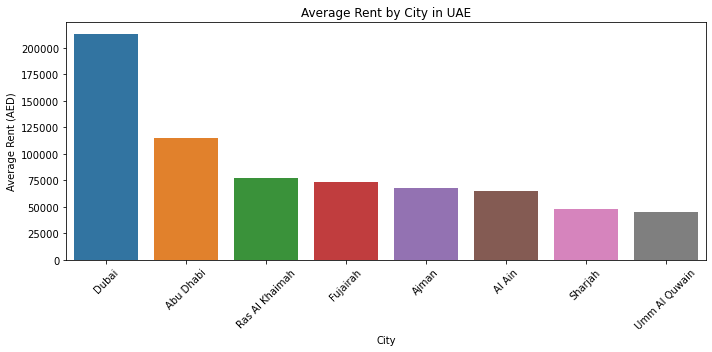

In [6]:
# Average rent by city
plt.figure(figsize=(10, 5))
city_rent = df.groupby('City')['Rent'].mean().sort_values(ascending=False)
sns.barplot(x=city_rent.index, y=city_rent.values)
plt.title('Average Rent by City in UAE')
plt.xlabel('City')
plt.ylabel('Average Rent (AED)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 🏡 Analysis 3: Average Rent by Property Type

This analysis shows how rental prices vary across different property types.
Understanding this helps both tenants and investors make informed decisions.

**Key Finding:** Residential Buildings have the highest average rent as they 
represent entire buildings, while Apartments are the most affordable option.

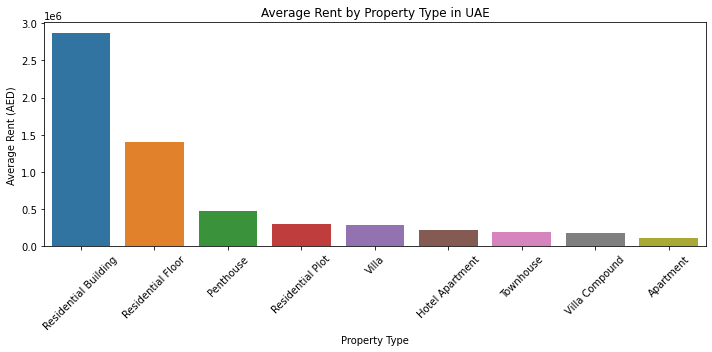

In [7]:
# Average rent by property type
plt.figure(figsize=(10, 5))
type_rent = df.groupby('Type')['Rent'].mean().sort_values(ascending=False)
sns.barplot(x=type_rent.index, y=type_rent.values)
plt.title('Average Rent by Property Type in UAE')
plt.xlabel('Property Type')
plt.ylabel('Average Rent (AED)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ✅ Conclusions

- **Apartments** are the most common property type in UAE (76% of all listings)
- **Dubai** is the most expensive emirate with average rent of ~210,000 AED/year
- **Umm Al Quwain** is the most affordable emirate
- **Residential Buildings** have the highest rent as they cover entire buildings
- **Villas and Penthouses** are premium options for high-end tenants